# Networks Analysis

In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

### Choose the networks to analyse

In [3]:
capacity_scenarios = ["germany_scenario1", "germany_scenario2"]

In [27]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_base2_"

### Create folder and paths

In [28]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [29]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.1 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [ ]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Demand",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

## Check

### Installed capacities 

In [44]:
component_specs = [("generators", "p_nom"), ("storage_units", "p_nom"), ("links", "p_nom")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
biomass               8020.00
PHS                   7361.72
OCGT                  6112.74
oil                   5684.35
ror                   4014.12
waste                 3127.66
hydro                  402.24
geothermal              26.90
battery charger          0.00
H2 Electrolysis          0.00
H2 Fuel Cell             0.00
battery discharger       0.00
offwind-float            0.00
offwind-dc               0.00
solar-hsat               0.00

Not Windy installed capacity by carrier [MW]
carrier
load                      inf
solar                86408.00
onwind               73332.07
CCGT                 30783.13
coal                 20351.94
lignite              19457.03
offwind-ac           11163.74
biomass               8020

### Line extension

In [45]:
for network in networks.values():
    log_print(f"\n{network.name} line capacities:")
    if "s_nom_opt" in network.lines and not network.lines.s_nom.equals(network.lines.s_nom_opt):
        log_print("  Line extension detected: 's_nom_opt' differs from 's_nom'.")
    else:
        log_print("  No line extension detected")


Windy line capacities:
  No line extension detected

Not Windy line capacities:
  No line extension detected

Wind Variability line capacities:
  No line extension detected


### Coal price 

In [46]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators in {network.name} from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators in Windy from 21.98
Marginal costs for 'coal' generators in Not Windy from 21.98
Marginal costs for 'coal' generators in Wind Variability from 21.98


### Components

In [47]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900


### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 16:00:00 with peak marginal price 253.92 €/MWh
Minimum marginal price across all buses at peak time: -19.12 €/MWh

Windy Marginal Price Statistics:
count    1350.000000
mean       17.040302
std        18.115447
min       -19.121476
25%         0.802762
50%        15.349809
75%        25.521340
max       253.915883

Plotting 'Not Windy' network at time 2025-04-08 05:00:00 with peak marginal price 143.43 €/MWh
Minimum marginal price across all buses at peak time: 21.44 €/MWh

Not Windy Marginal Price Statistics:
count    1350.000000
mean       58.324722
std         7.929503
min        21.442339
25%        53.494954
50%        56.740081
75%        61.404945
max       143.429463

Plotting 'Wind Variability' network at time 2025-10-06 06:00:00 with peak marginal price 1112.26 €/MWh
Minimum marginal price across all buses at peak time: -29.24 €/MWh

Wind Variability Marginal Price Statistics:
count    1350.000000
mean       40.993829
std        67.

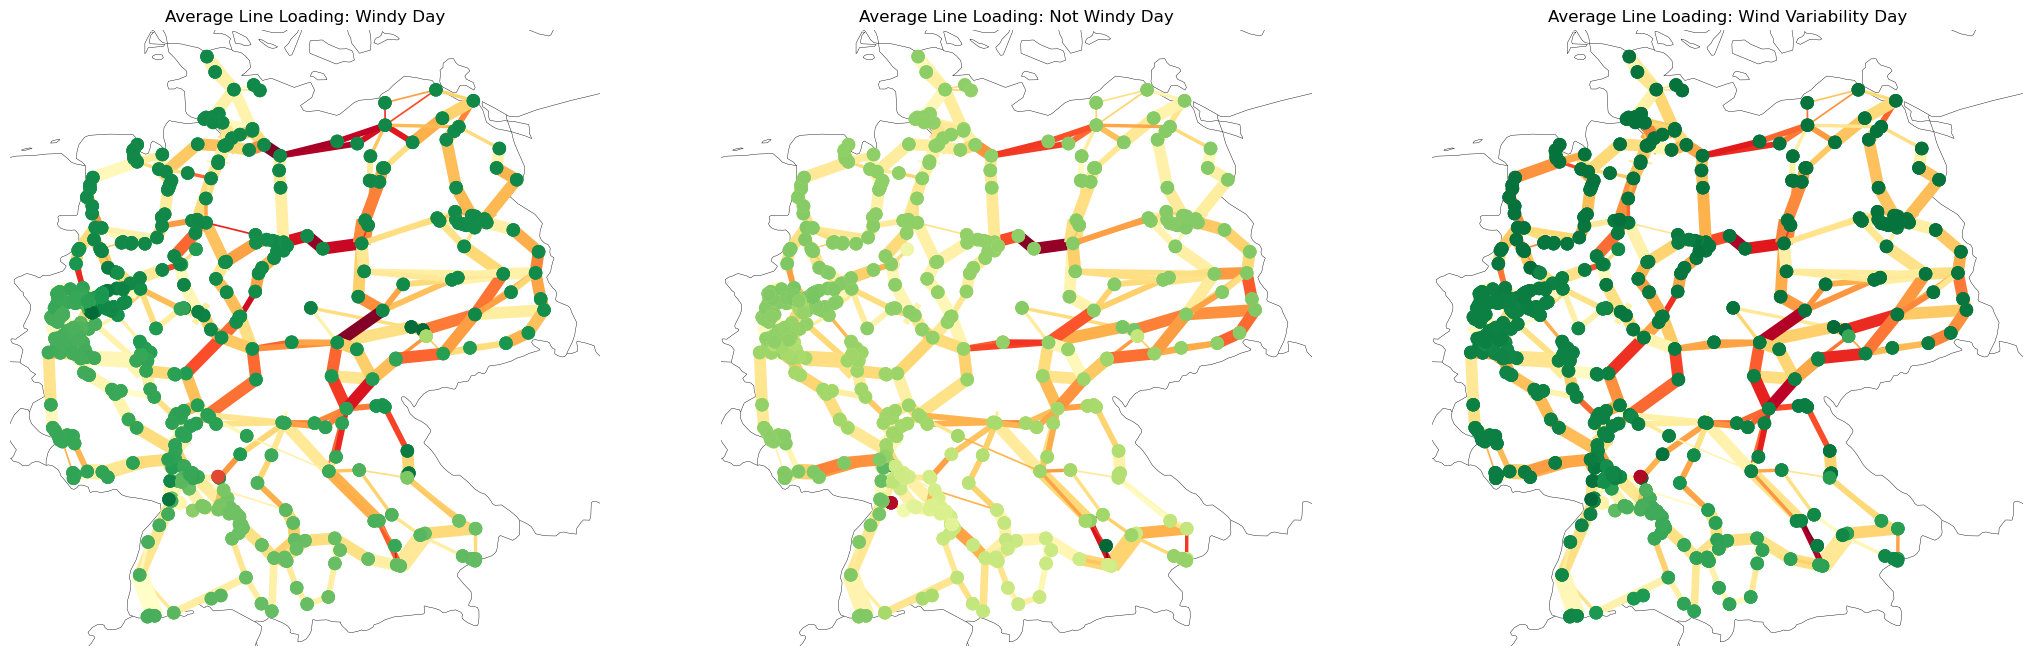

In [48]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01,
        bus_colors=peak_prices,
        bus_cmap='RdYlGn_r',
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400,
    )

    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], "Average Line Loading: " + n.name + " Day")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print("")
    i += 1

save_fig(fig, "02_marginal_prices.png")

##### Average Marginal Price by Snapshot

Network: Windy
count    24.000000
mean     14.581968
std       2.123557
min      11.460438
25%      12.016388
50%      15.314621
75%      16.355015
max      17.073217

Network: Not Windy
count    24.000000
mean     54.523992
std       4.581464
min      44.582121
25%      50.833895
50%      57.066327
75%      57.594233
max      58.324722

Network: Wind Variability
count    24.000000
mean     41.099507
std       2.992930
min      35.164203
25%      40.785582
50%      40.909608
75%      42.912536
max      45.328685

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/02_average_marginal_prices.png


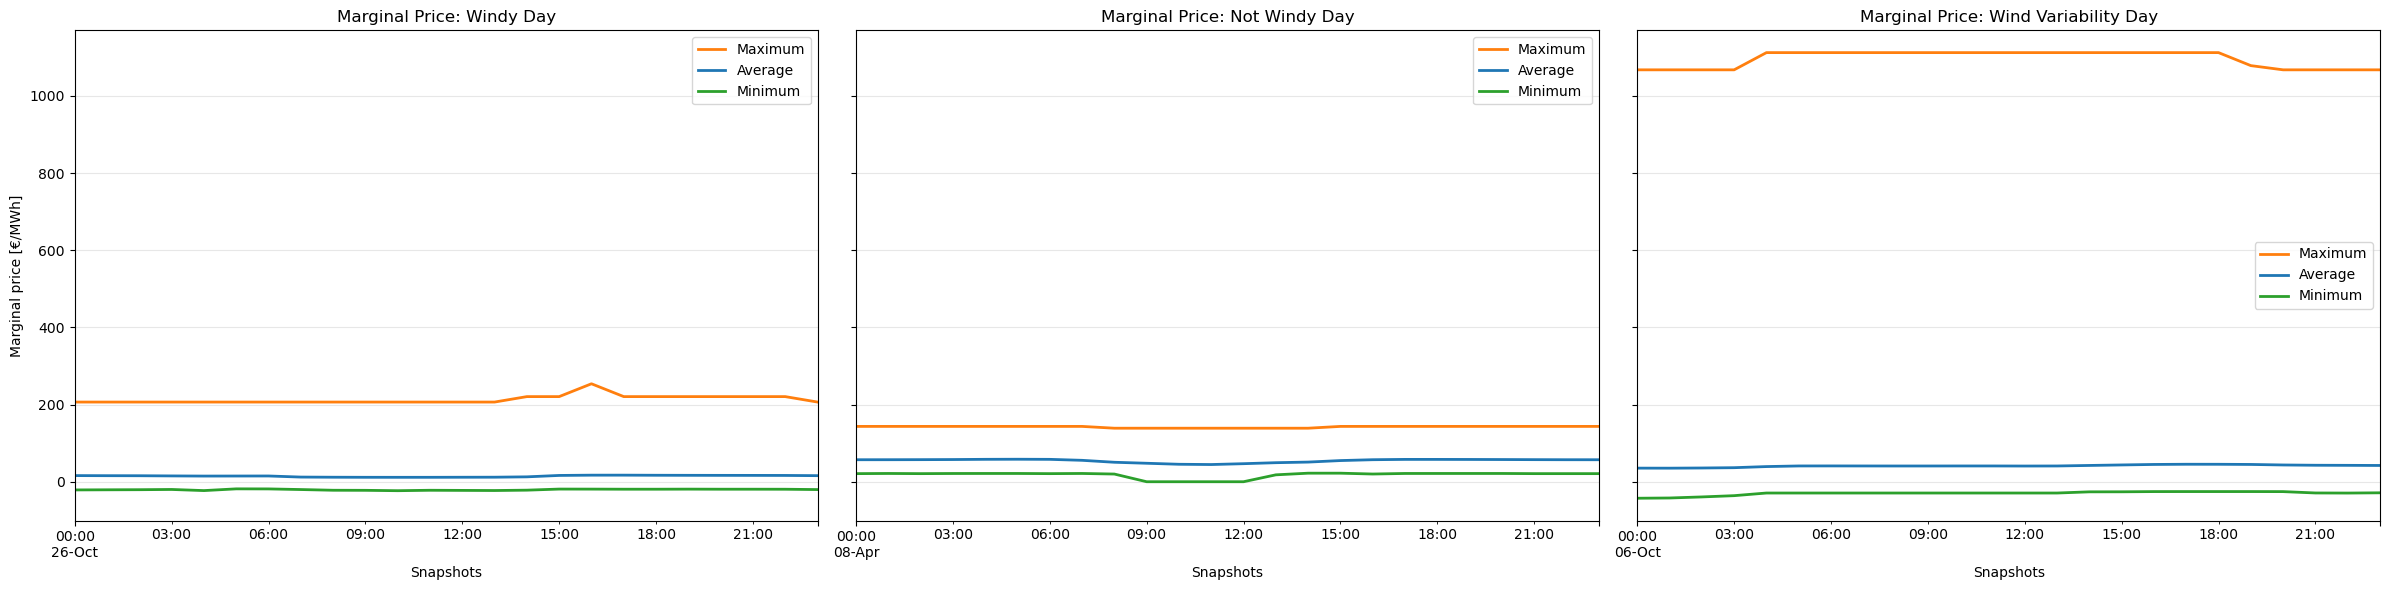

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

for ax, network in zip(axes, [n1, n2, n3]):
    if network.buses_t.marginal_price.empty:
        avg_marginal_price = pd.Series(0.0, index=network.snapshots)
        min_marginal_price = pd.Series(0.0, index=network.snapshots)
        max_marginal_price = pd.Series(0.0, index=network.snapshots)
        log_print(f"No marginal price data found for {network.name}.")
    else:
        avg_marginal_price = network.buses_t.marginal_price.mean(axis=1)
        min_marginal_price = network.buses_t.marginal_price.min(axis=1)
        max_marginal_price = network.buses_t.marginal_price.max(axis=1)
    
    max_marginal_price.plot(ax=ax, color="tab:orange", lw=2)
    avg_marginal_price.plot(ax=ax, color="tab:blue", lw=2)
    min_marginal_price.plot(ax=ax, color="tab:green", lw=2)
   
    ax.set_title(f"Marginal Price: {network.name} Day" )
    ax.set_xlabel("Snapshots")
    ax.set_ylabel("Marginal price [€/MWh]")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(["Maximum", "Average", "Minimum"])

    log_print("=" * 70)
    log_print(f"Network: {network.name}")
    log_print(avg_marginal_price.describe().to_string())
    log_print("=" * 70)
    log_print("")

fig.tight_layout()
save_fig(fig, "02_average_marginal_prices.png")

### Load shedding

 Network: Windy
  Average loading across all lines: 15.52%
  Max average loading: 66.46%
  Lines with >60% avg loading: 4
  Lines with >70% avg loading: 0

 Network: Not Windy
  Average loading across all lines: 11.85%
  Max average loading: 52.28%
  Lines with >60% avg loading: 0
  Lines with >70% avg loading: 0

 Network: Wind Variability
  Average loading across all lines: 17.02%
  Max average loading: 62.65%
  Lines with >60% avg loading: 1
  Lines with >70% avg loading: 0

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/03_load_shedding.png


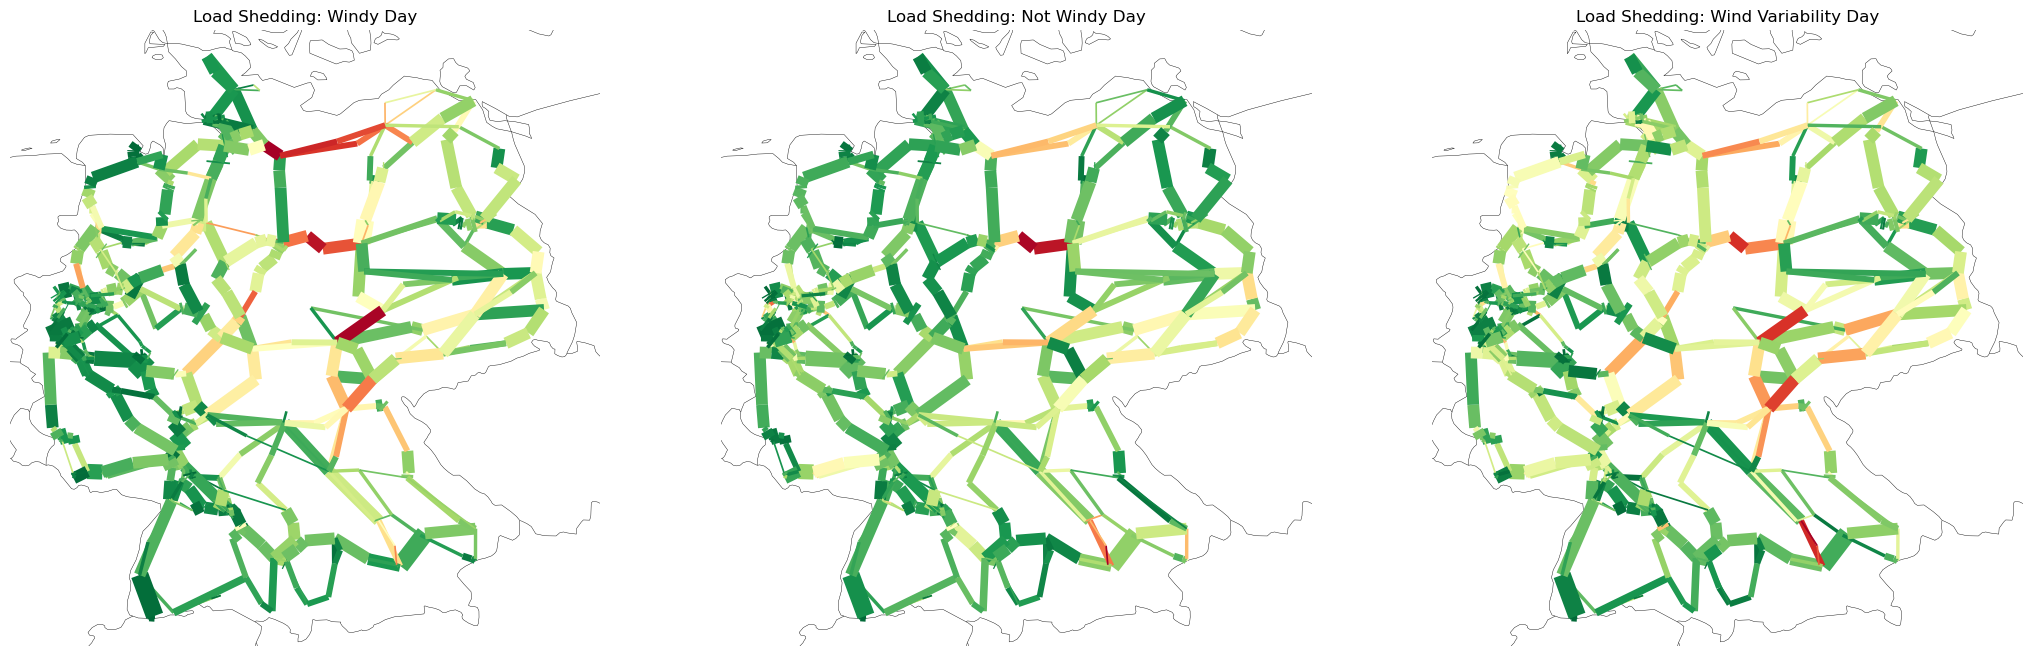

In [50]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/5000,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], "Load Shedding: " + n.name + " Day")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

save_fig(fig, "03_load_shedding.png")

In [51]:
n.links.groupby("carrier").sum()

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,679.460093,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,2213.758325,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,3436.536930,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,3507.400817,0


##### Offshore Wind Curtailment


#### Parameter Documentation for New Curtailment Function

**Parameters Used:**

1. **`generators.p_nom`** (static, MW) — Installed/nameplate capacity
   - *Why:* Represents the fixed maximum power the generator can produce (unless extendable).
   - *Used when:* Generator capacity was not optimized.

2. **`generators.p_nom_opt`** (output, MW) — Optimized capacity after solving
   - *Why:* After optimization, if `p_nom_extendable=True`, this holds the actual capacity built. For post-solve analysis, we should use this.
   - *Fallback:* If `p_nom_opt` is NaN, we fall back to `p_nom`.
   - **This is the key fix:** The old function ignored optimization, always using `p_nom`.

3. **`generators_t.p_max_pu`** (time series, per unit, 0-1) — Maximum output availability factor
   - *Why:* For renewables, this is the capacity factor from weather (wind speed, solar irradiance). For conventional plants, it's the de-rating factor (maintenance, forced outages, etc.).
   - *Formula:* Available Power[t] = `p_max_pu[t]` × `p_nom_eff`

4. **`generators_t.p`** (time series, MW) — Actual dispatched power (solver output)
   - *Why:* This is what was actually generated. Curtailment = Available − Dispatched.

5. **`generators.carrier`** (string) — Energy carrier type (e.g., 'onwind', 'offwind-ac', 'solar')
   - *Why:* Allows filtering/grouping by technology type for separate analysis.

**The Curtailment Equation:**

$$\text{Curtailed Power}[t] = \max\left(0, \, p\_max\_pu[t] \times p\_nom\_eff \, - \, p[t] \right)$$

where $p\_nom\_eff = p\_nom\_opt$ if extendable (and not NaN), otherwise $p\_nom$.


In [ ]:
def plot_curtailment(n, carrier, ax):
    # Time-series available / dispatched / curtailed aggregated by carrier
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = (p_available_by_carrier - p_by_carrier).clip(lower=0)

    # Use friendly display name for labels
    carrier_display = carrier_label(carrier)
    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    # Build a dataframe using display-name columns so matplotlib legend shows them
    p_df = pd.DataFrame(
        {
            carrier_display + " dispatched": p_by_carrier[carrier],
            carrier_display + " curtailed": p_curtailed_by_carrier[carrier],
            carrier_display + " available": p_available_by_carrier[carrier],
        }
    )
    p_df[carrier_display + " capacity"] = capacity

    # Plot stacked dispatched + curtailed area, then available and capacity lines
    p_df[[carrier_display + " dispatched", carrier_display + " curtailed"]].plot(kind="area", ax=ax, lw=0)
    p_df[[carrier_display + " available", carrier_display + " capacity"]].plot(ax=ax)

    # Compute totals for logging
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()

    # Axis formatting and explicit legend using the display-name columns
    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df[carrier_display + " capacity"].max() * 1.1 if hasattr(p_df[carrier_display + " capacity"], "max") else None])
    ax.set_title(f"{carrier_display} Curtailment: {n.name} Day")

    # Ensure legend shows the display names in a clear order
    legend_labels = list(p_df.columns)
    ax.legend(legend_labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.12), frameon=False)

    # Log summary using display-name
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier_display} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier):.2f}")
    log_print(f"Total available (MWh): {tot_av:.2f}")
    log_print(f"Total dispatched (MWh): {tot_disp:.2f}")
    log_print(f"Total curtailed (MWh): {tot_cur:.2f}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan'):.2f}")
    log_print("=" * 70)
    log_print("")

#### offwind

Network: Windy
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 236217.48
Total dispatched (MWh): 37499.90
Total curtailed (MWh): 198717.58
Curtailed fraction: 0.84

Network: Not Windy
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 8316.63
Total dispatched (MWh): 8316.62
Total curtailed (MWh): 0.01
Curtailed fraction: 0.00

Network: Wind Variability
Offshore wind (AC) capacity MW: 11163.74
Total available (MWh): 173568.76
Total dispatched (MWh): 69168.05
Total curtailed (MWh): 104400.71
Curtailed fraction: 0.60

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/04_offwind_curtailment.png


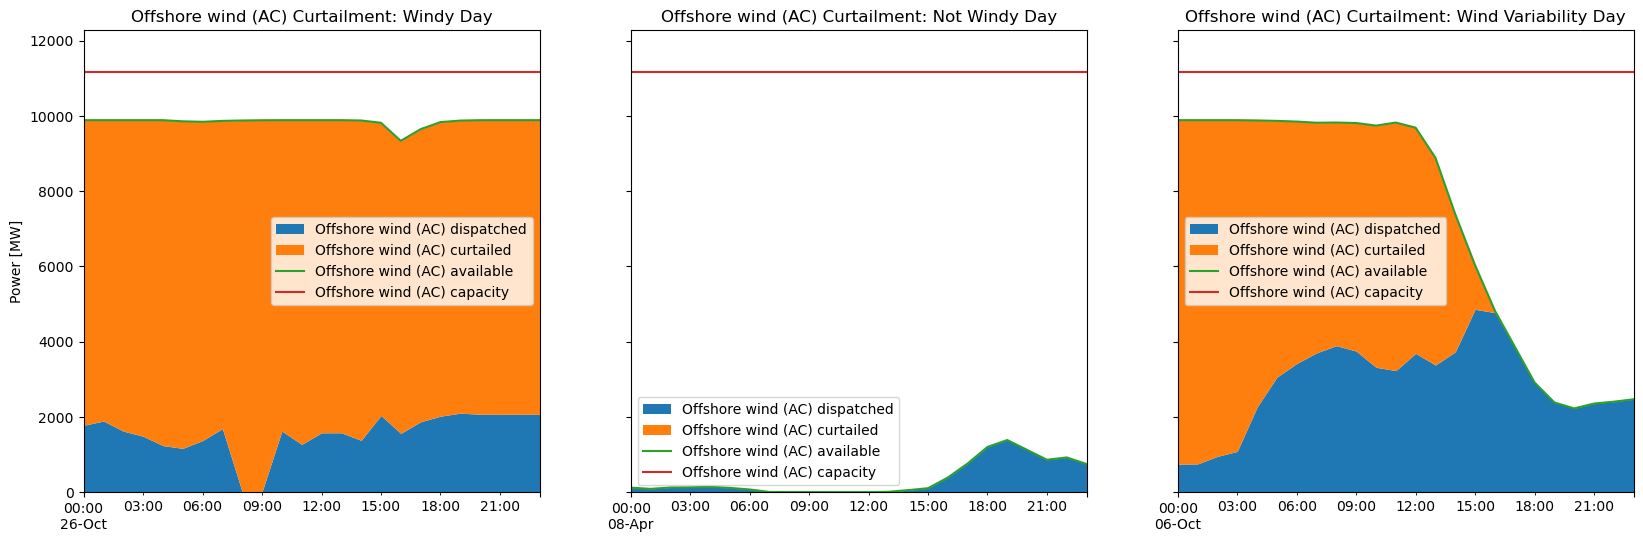

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

save_fig(fig, "04_offwind_curtailment.png")

#### onwind

Network: Windy
Onshore wind capacity MW: 73332.07
Total available (MWh): 1520776.20
Total dispatched (MWh): 891757.66
Total curtailed (MWh): 629018.54
Curtailed fraction: 0.41

Network: Not Windy
Onshore wind capacity MW: 73332.07
Total available (MWh): 49435.40
Total dispatched (MWh): 49435.00
Total curtailed (MWh): 0.40
Curtailed fraction: 0.00

Network: Wind Variability
Onshore wind capacity MW: 73332.07
Total available (MWh): 804830.80
Total dispatched (MWh): 627686.43
Total curtailed (MWh): 177144.37
Curtailed fraction: 0.22

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/05_onwind_curtailment.png


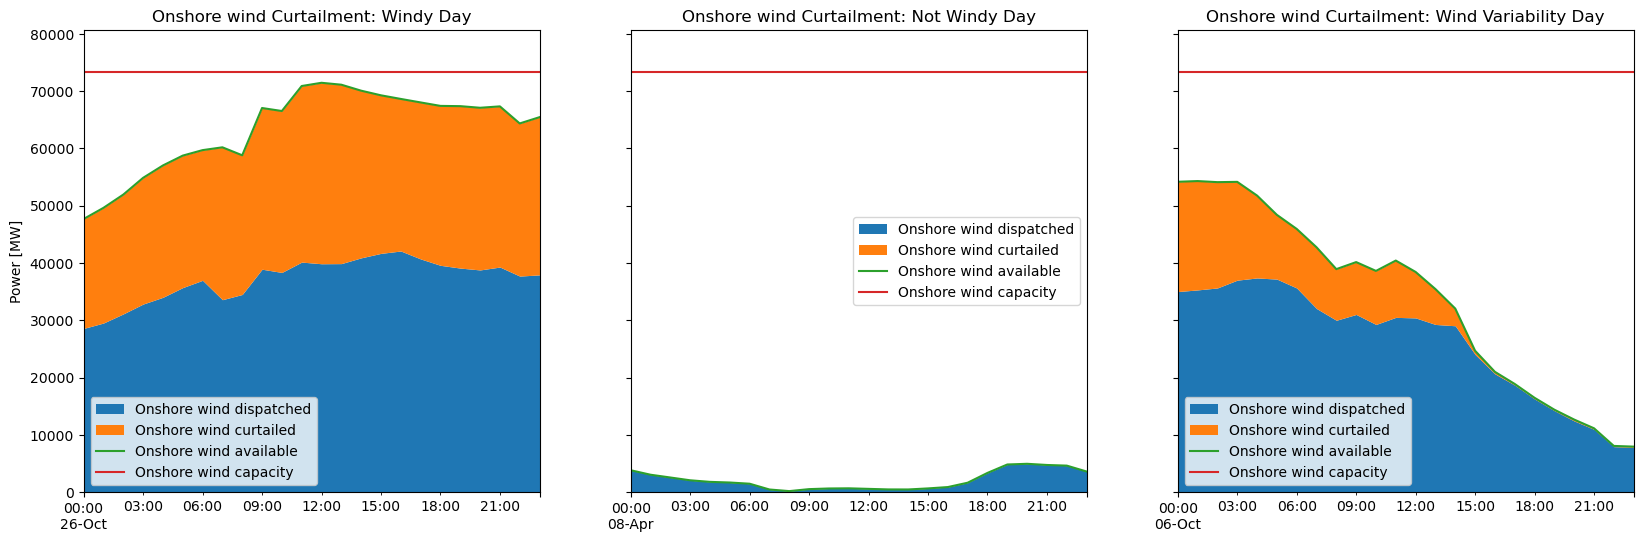

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

save_fig(fig, "05_onwind_curtailment.png")

#### solar

Network: Windy
Solar PV capacity MW: 86408.00
Total available (MWh): 121780.28
Total dispatched (MWh): 109658.49
Total curtailed (MWh): 12121.79
Curtailed fraction: 0.10

Network: Not Windy
Solar PV capacity MW: 86408.00
Total available (MWh): 438181.16
Total dispatched (MWh): 438048.79
Total curtailed (MWh): 132.37
Curtailed fraction: 0.00

Network: Wind Variability
Solar PV capacity MW: 86408.00
Total available (MWh): 90121.28
Total dispatched (MWh): 83814.86
Total curtailed (MWh): 6306.42
Curtailed fraction: 0.07

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/05_solar_curtailment.png


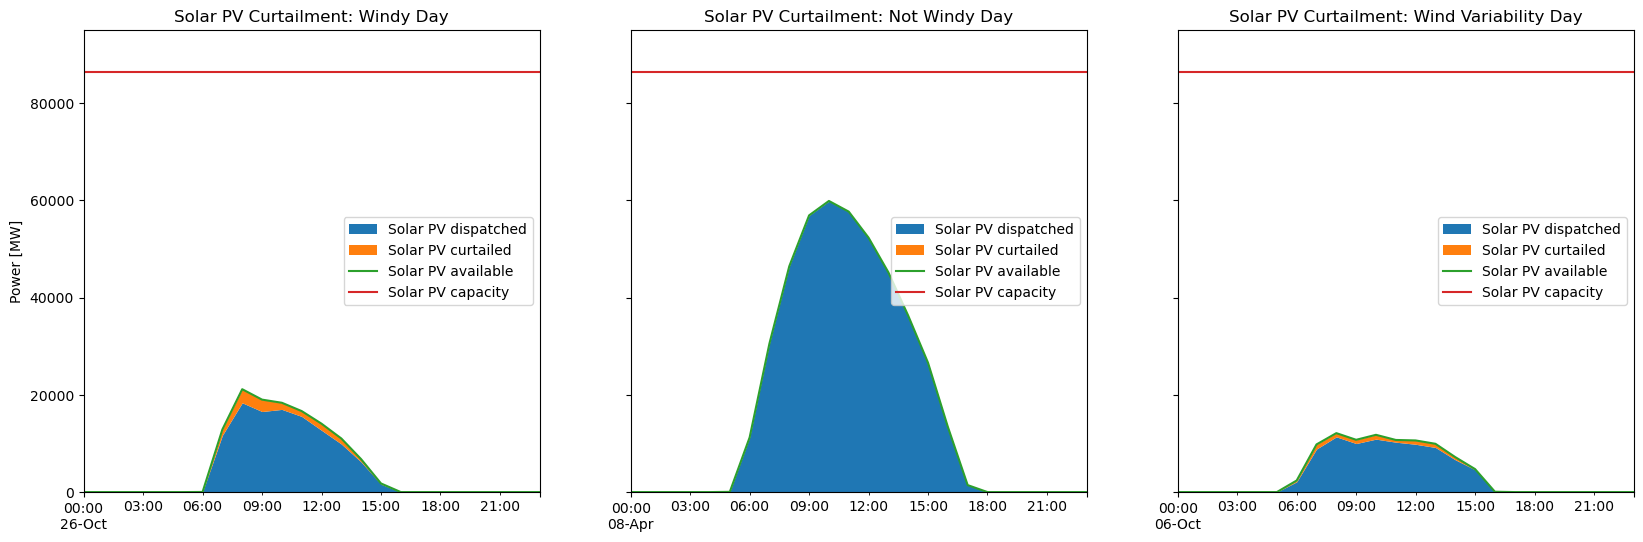

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "solar", axes[0])
plot_curtailment(n2, "solar", axes[1])
plot_curtailment(n3, "solar", axes[2])

save_fig(fig, "05_solar_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/06_power_dispatch.png


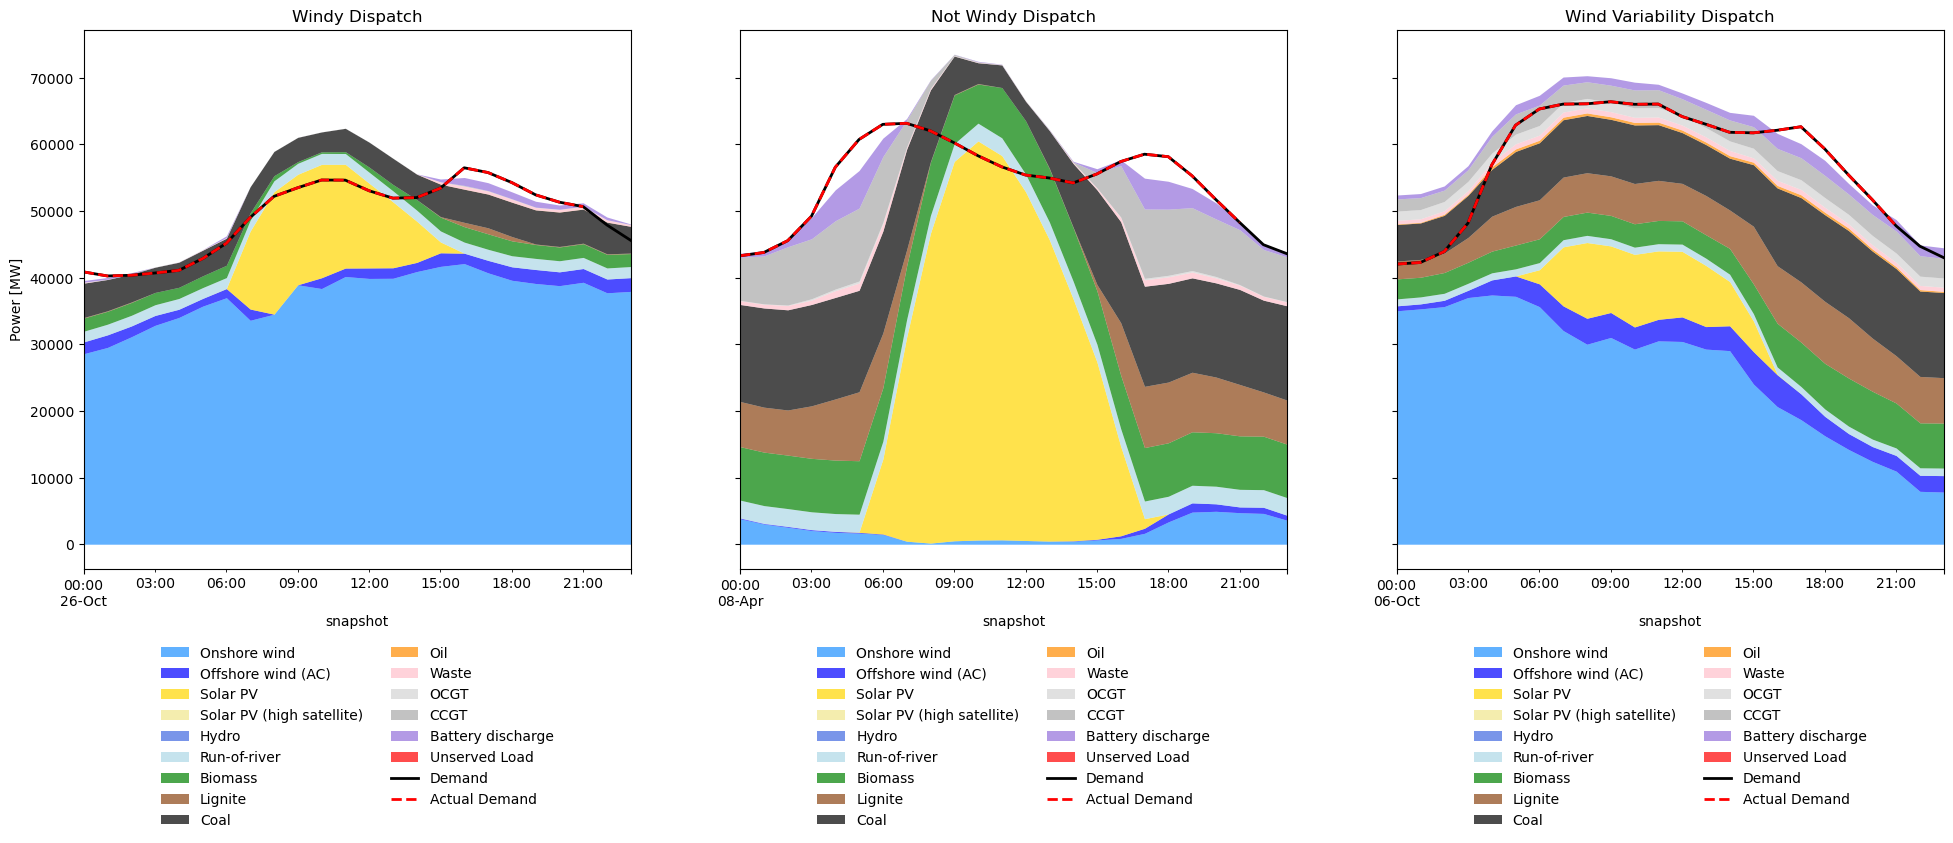

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "battery discharge": "mediumpurple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "battery discharge",
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]
    p_by_carrier.columns = [carrier_label(col) for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve (use display name)
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="black", lw=2, label=carrier_label('load'))

    scenario_title = n.name

    real_data = pd.read_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv", index_col=0, parse_dates=True)
    demand_real = real_data["grid load"]
    # Use simulation snapshots as index for real data to align with simulation time axis
    demand_real = pd.Series(demand_real.values, index=n.snapshots, name=carrier_label('load') + " (actual)")
    # Shift real data by two hours
    demand_real = demand_real.shift(-2)
    demand_real.plot(ax=ax, color="red",  linestyle="--", lw=2, label=carrier_label('load') + " (actual)")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

save_fig(fig, "06_power_dispatch.png")

##### Total Energy Production by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_base2_/07_energy_production.png

=== Energy Production Summary ===
                            Windy      Not Windy  Wind Variability
Onshore wind        891757.662632   49434.998816     627686.430574
Solar PV            109658.493065  438048.790985      83814.861702
Coal                102874.846124  291254.743196     223876.245631
Biomass              38043.343011  189052.241738     110102.967891
Lignite               2886.891292  124086.081099     149480.514605
CCGT                   235.855601  138389.162877      65857.468318
Run-of-river         39367.558978   63869.595498      26076.924715
Offshore wind (AC)   37499.900053    8316.624031      69168.049141
OCGT                   610.842198    2469.177443      33914.778713
Waste                 3552.284328   12751.476744      16591.156770
Oil                    147.166053       0.684168       7656.838866
Geothermal             512.975335     645.589503     

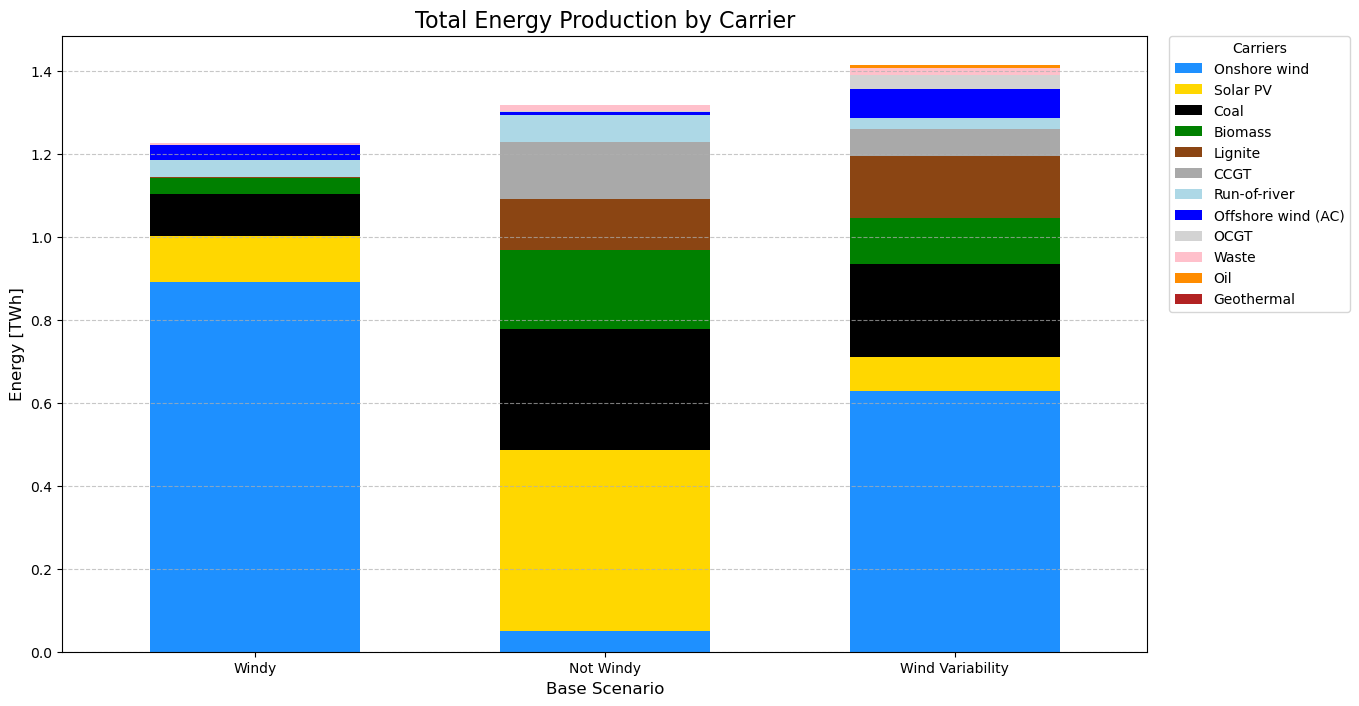

In [41]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]
carrier_keys = list(energy_df.index)
energy_df.index = [carrier_label(carrier) for carrier in carrier_keys]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in carrier_keys]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

save_fig(fig, "07_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [22]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Windy day: 146.66 kg CO2
Total CO2 emissions at the Not Windy day: 438356.16 kg CO2
Total CO2 emissions at the Wind Variability day: 255228.20 kg CO2




### Statistics

In [23]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        3.078313e+04        3.078313e+04  3.410000e-03  0.000000e+00    3.410000e-03       0.00000     4.547946e-09  7.387951e+05         1.066291e+07                  0.15964  3.940000e-03      1.142857
            Offshore Wind (AC)        1.116374e+04        1.116374e+04  6.535762e+04  0.000000e+00    6.535762e+04       0.00000     2.439356e-01  1.708599e+05         9.110722e+06               1571.43889  1.608788e+03      0.024615
            Onshore Wind              7.333207e+04        7.333207e+04  1.007248e+06  0.000000e+00    1.007248e+06       0.00000     5.723099e-01  5.135282e+05         2.387208e+07              24952.14206  3.530029e+05      0.350463
            Open-Cyc